# Notebook 01 — Data Ingestion
### SemEval-2018 Task 1: Affect in Tweets

Αυτό το notebook φορτώνει το **SemEval-2018 Task 1** dataset από το HuggingFace Hub, εξερευνεί τη δομή και τα στατιστικά του, και το αποθηκεύει σε Parquet format για χρήση στα επόμενα notebooks.

Χρησιμοποιούμε το **Subtask E-c (multi-label emotion classification)** — κάθε tweet είναι annotated με **11 emotions**:
`anger`, `anticipation`, `disgust`, `fear`, `joy`, `love`, `optimism`, `pessimism`, `sadness`, `surprise`, `trust`

> **Σκοπός:** Φόρτωση raw data → Exploratory Data Analysis → Αποθήκευση σε Parquet

## 1. Imports & Αρχικοποίηση Περιβάλλοντος

Φορτώνουμε τις απαραίτητες βιβλιοθήκες και δημιουργούμε τους φακέλους αποθήκευσης. Βασικές βιβλιοθήκες: `pandas` για tabular data, `matplotlib`/`seaborn` για visualizations, `datasets` (HuggingFace) για φόρτωση του dataset απευθείας από το Hub.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datasets import load_dataset, get_dataset_config_names

# Paths
DATA_DIR = os.path.join('..', 'data')
RAW_DIR  = os.path.join(DATA_DIR, 'semeval2018')
PROC_DIR = os.path.join(DATA_DIR, 'processed')
os.makedirs(RAW_DIR,  exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)

print('Directories ready')
print(f'   RAW  → {os.path.abspath(RAW_DIR)}')
print(f'   PROCESSED → {os.path.abspath(PROC_DIR)}')

Directories ready
   RAW  → /home/konstantinos-papadogiannis/Desktop2/SocialMediaAgent/data/semeval2018
   PROCESSED → /home/konstantinos-papadogiannis/Desktop2/SocialMediaAgent/data/processed


**Αποτέλεσμα:** Οι βιβλιοθήκες φορτώθηκαν επιτυχώς. Βασικές: `pandas` για tabular data, `matplotlib`/`seaborn` για visualizations, `datasets` (HuggingFace) για φόρτωση του dataset απευθείας από το Hub χωρίς manual download. Οι φάκελοι `data/semeval2018/` και `data/processed/` δημιουργήθηκαν αυτόματα.

## 2. Διερεύνηση Διαθέσιμων Configurations

Το SemEval-2018 Task 1 στο HuggingFace Hub έχει πολλαπλά subtasks και γλώσσες. Εδώ εντοπίζουμε τα διαθέσιμα αγγλικά configurations ώστε να επιλέξουμε το κατάλληλο για το project.

In [2]:
print('Fetching available dataset configurations...')
all_configs = get_dataset_config_names('sem_eval_2018_task_1', trust_remote_code=True)

# Keep only English configurations
configs = [c for c in all_configs if c.endswith('.english')]

print(f'Found {len(configs)} English configurations (out of {len(all_configs)} total):\n')
for c in configs:
    print(f'  • {c}')


Fetching available dataset configurations...
Found 1 English configurations (out of 3 total):

  • subtask5.english


## 3. Φόρτωση Dataset — Multi-Label Emotion Classification

**Configuration:** `subtask5.english`

**Γιατί το Subtask E-c;** Παρέχει 11 emotion labels ανά tweet σε μορφή multi-label, κάτι που είναι πολύ πλουσιότερο από ένα απλό 3-class sentiment (positive/negative/neutral). Κάθε tweet μπορεί να εκφράζει ταυτόχρονα πολλαπλά emotions.

Δεν χρειάζεται να ορίσουμε δικό μας threshold — τα binary labels (0/1) έχουν ήδη παρθεί από ανθρώπινους annotators. Χρησιμοποιούμε τα splits ως έχουν: **train** για εκπαίδευση, **validation** για hyperparameter tuning, **test** για τελική αξιολόγηση.

**Αποτέλεσμα:** Από τα 3 συνολικά configurations του `sem_eval_2018_task_1` στο HuggingFace Hub, μόνο **1 είναι αγγλικό**: το `subtask5.english`, που αντιστοιχεί στο Subtask E-c (multi-label emotion classification με 11 κατηγορίες). Τα υπόλοιπα 2 αφορούν άλλες γλώσσες ή subtasks. Αυτό επιβεβαιώνει ότι χρησιμοποιούμε το σωστό configuration.

In [3]:
DATASET_CONFIG = 'subtask5.english'

print(f'Loading SemEval-2018 Task 1 — {DATASET_CONFIG}...')
dataset = load_dataset(
    'sem_eval_2018_task_1',
    DATASET_CONFIG,
    trust_remote_code=True
)

print('\n Dataset loaded successfully!')
print(dataset)

Loading SemEval-2018 Task 1 — subtask5.english...

 Dataset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['ID', 'Tweet', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust'],
        num_rows: 6838
    })
    test: Dataset({
        features: ['ID', 'Tweet', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust'],
        num_rows: 3259
    })
    validation: Dataset({
        features: ['ID', 'Tweet', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust'],
        num_rows: 886
    })
})


## 4. Επιθεώρηση Δομής Dataset

Ελέγχουμε τον αριθμό δειγμάτων ανά split, τα ονόματα των columns και τους τύπους δεδομένων (features). Σημαντικό: τα emotion columns είναι τύπου `bool` (True/False) — θα τα μετατρέψουμε σε `int` (0/1) στο επόμενο βήμα.

In [4]:
# Check splits and sizes
print('=== Dataset Splits ===')
for split_name, split_data in dataset.items():
    print(f'  {split_name:12s}: {len(split_data):>5,} samples')

print(f'\n=== Columns ===')
print(dataset['train'].column_names)

print(f'\n=== Features ===')
print(dataset['train'].features)

=== Dataset Splits ===
  train       : 6,838 samples
  test        : 3,259 samples
  validation  :   886 samples

=== Columns ===
['ID', 'Tweet', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

=== Features ===
{'ID': Value(dtype='string', id=None), 'Tweet': Value(dtype='string', id=None), 'anger': Value(dtype='bool', id=None), 'anticipation': Value(dtype='bool', id=None), 'disgust': Value(dtype='bool', id=None), 'fear': Value(dtype='bool', id=None), 'joy': Value(dtype='bool', id=None), 'love': Value(dtype='bool', id=None), 'optimism': Value(dtype='bool', id=None), 'pessimism': Value(dtype='bool', id=None), 'sadness': Value(dtype='bool', id=None), 'surprise': Value(dtype='bool', id=None), 'trust': Value(dtype='bool', id=None)}


In [5]:
# Show a few examples
print('=== Sample Tweets ===')
for i in range(3):
    row = dataset['train'][i]
    print(f'\n[{i+1}] Tweet: {row["Tweet"]}')
    # Print active emotion labels
    emotions = ['anger','anticipation','disgust','fear','joy',
                'love','optimism','pessimism','sadness','surprise','trust']
    active = [e for e in emotions if row.get(e, 0) == 1]
    print(f'     Emotions: {active if active else ["(none)"]}') 

=== Sample Tweets ===

[1] Tweet: “Worry is a down payment on a problem you may never have'.  Joyce Meyer.  #motivation #leadership #worry
     Emotions: ['anticipation', 'optimism', 'trust']

[2] Tweet: Whatever you decide to do make sure it makes you #happy.
     Emotions: ['joy', 'love', 'optimism']

[3] Tweet: @Max_Kellerman  it also helps that the majority of NFL coaching is inept. Some of Bill O'Brien's play calling was wow, ! #GOPATS
     Emotions: ['anger', 'disgust', 'joy', 'optimism']


**Αποτέλεσμα:** Το dataset φορτώθηκε επιτυχώς ως `DatasetDict` με 3 splits: **Train** (6.838 tweets) για εκπαίδευση, **Test** (3.259 tweets) για τελική αξιολόγηση — δεν το "βλέπουμε" κατά το training για να αποφύγουμε data leakage, και **Validation** (886 tweets) για hyperparameter tuning. Κάθε δείγμα έχει `ID`, `Tweet` και 11 boolean columns — ένα ανά emotion.

## 5. Μετατροπή σε Pandas DataFrames

Μετατρέπουμε τα HuggingFace `Dataset` objects σε pandas DataFrames για ευκολότερη ανάλυση. Ταυτόχρονα αλλάζουμε τα emotion columns από `bool` σε `int` (0/1), ώστε να υποστηρίζουν αριθμητικές πράξεις όπως `.sum()`, `.mean()` και matrix multiplication — απαραίτητες για τα επόμενα classification experiments.

In [6]:
EMOTIONS = ['anger', 'anticipation', 'disgust', 'fear', 'joy',
            'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

def split_to_df(split):
    df = split.to_pandas()
    # Ensure all emotion columns are integer (0/1)
    for e in EMOTIONS:
        if e in df.columns:
            df[e] = df[e].astype(int)
    return df

df_train = split_to_df(dataset['train'])
df_val   = split_to_df(dataset['validation'])
df_test  = split_to_df(dataset['test'])

print(f'Training set   : {df_train.shape}')
print(f'Validation set : {df_val.shape}')
print(f'Test set       : {df_test.shape}')
print()
df_train.head()

Training set   : (6838, 13)
Validation set : (886, 13)
Test set       : (3259, 13)



,ID,Tweet,anger,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
0,2017-En-21441,“Worry is a down payment on a problem you may ...,0,1,0,0,0,0,1,0,0,0,1
1,2017-En-31535,Whatever you decide to do make sure it makes y...,0,0,0,0,1,1,1,0,0,0,0
2,2017-En-21068,@Max_Kellerman it also helps that the majorit...,1,0,1,0,1,0,1,0,0,0,0
3,2017-En-31436,Accept the challenges so that you can literall...,0,0,0,0,1,0,1,0,0,0,0
4,2017-En-22195,My roommate: it's okay that we can't spell bec...,1,0,1,0,0,0,0,0,0,0,0


## 6. Στατιστικά Dataset

Υπολογίζουμε global στατιστικά για το σύνολο (train + validation + test). Στόχος: να κατανοήσουμε την κατανομή των emotion labels και να εντοπίσουμε τυχόν **class imbalance** — κρίσιμο χαρακτηριστικό που επηρεάζει άμεσα τη στρατηγική εκπαίδευσης των classifiers.

In [7]:
# Combine all splits for global stats
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
df_all['split'] = (['train'] * len(df_train) +
                   ['validation'] * len(df_val) +
                   ['test'] * len(df_test))

print('=== Global Statistics ===')
print(f'Total tweets   : {len(df_all):,}')
print(f'Unique tweets  : {df_all["Tweet"].nunique():,}')
print(f'Avg tweet len  : {df_all["Tweet"].str.len().mean():.1f} chars')
print(f'Max tweet len  : {df_all["Tweet"].str.len().max()} chars')

# Emotion counts
emotion_counts = df_all[EMOTIONS].sum().sort_values(ascending=False)
print(f'\n=== Emotion Label Counts (all splits) ===')
for emotion, count in emotion_counts.items():
    bar = '█' * int(count / 50)
    print(f'  {emotion:14s}: {count:>4} {bar}')

=== Global Statistics ===
Total tweets   : 10,983
Unique tweets  : 10,983
Avg tweet len  : 94.8 chars
Max tweet len  : 160 chars

=== Emotion Label Counts (all splits) ===
  joy           : 4319 ██████████████████████████████████████████████████████████████████████████████████████
  disgust       : 4020 ████████████████████████████████████████████████████████████████████████████████
  anger         : 3960 ███████████████████████████████████████████████████████████████████████████████
  optimism      : 3434 ████████████████████████████████████████████████████████████████████
  sadness       : 3233 ████████████████████████████████████████████████████████████████
  fear          : 1848 ████████████████████████████████████
  anticipation  : 1527 ██████████████████████████████
  love          : 1348 ██████████████████████████
  pessimism     : 1270 █████████████████████████
  surprise      :  566 ███████████
  trust         :  553 ███████████


**Αποτέλεσμα:** Τα emotion columns είναι τύπου `bool` (True/False). Στο επόμενο βήμα τα μετατρέπουμε σε `int` (0/1) ώστε να υποστηρίζουν αριθμητικές πράξεις όπως `.sum()`, `.mean()` και matrix multiplication — απαραίτητες για τα classification experiments του NB04.

In [8]:
# Number of emotions per tweet
df_all['n_emotions'] = df_all[EMOTIONS].sum(axis=1)
print('=== Number of Emotions per Tweet ===')
print(df_all['n_emotions'].value_counts().sort_index().to_string())
print(f'\nAvg emotions/tweet : {df_all["n_emotions"].mean():.2f}')
print(f'Max emotions/tweet : {df_all["n_emotions"].max()}')

=== Number of Emotions per Tweet ===
n_emotions
0     293
1    1481
2    4491
3    3459
4    1073
5     170
6      16

Avg emotions/tweet : 2.37
Max emotions/tweet : 6


## 7. Οπτικοποιήσεις (Visualizations)

Δημιουργούμε τρία διαγράμματα για οπτική κατανόηση του dataset:
1. **Emotion frequency + multi-label distribution** — πόσα tweets έχουν κάθε emotion και πόσα emotions έχει κάθε tweet κατά μέσο όρο
2. **Emotion co-occurrence heatmap** — ποια emotions εμφανίζονται συχνά ταυτόχρονα στο ίδιο tweet
3. **Κατανομή ανά split** — επαλήθευση ότι τα train/validation/test έχουν παρόμοια κατανομή (απουσία distribution shift)

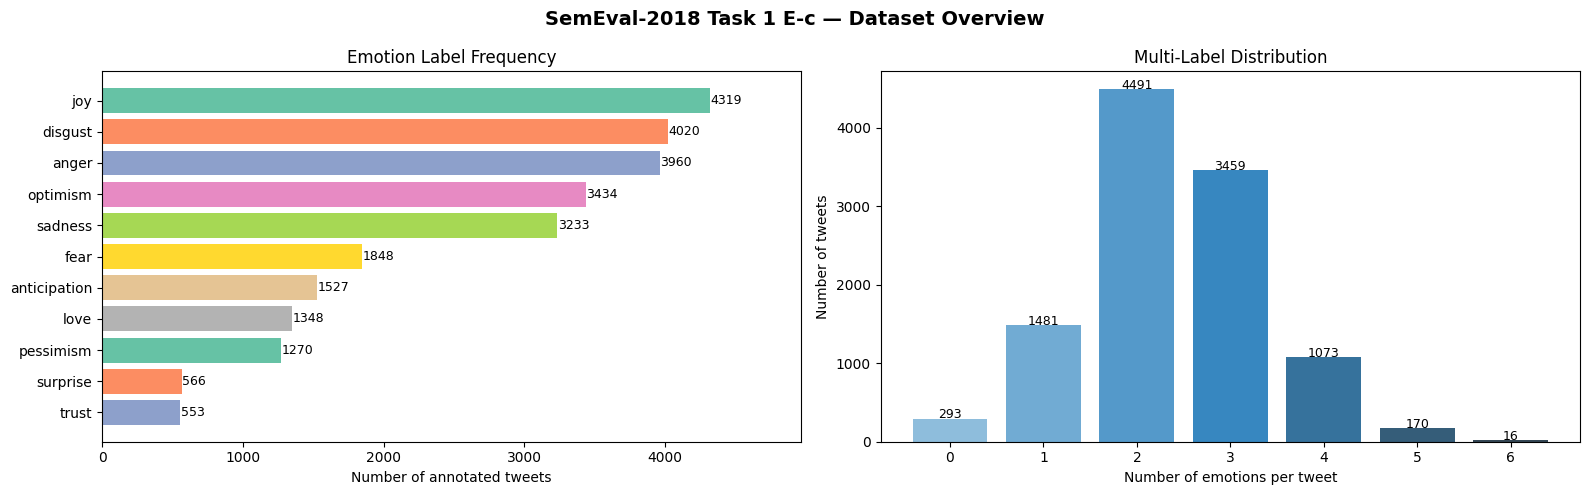

Figure saved to data/processed/dataset_overview.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('SemEval-2018 Task 1 E-c — Dataset Overview', fontsize=14, fontweight='bold')

# --- Plot 1: Emotion frequency ---
ax1 = axes[0]
colors = sns.color_palette('Set2', len(EMOTIONS))
bars = ax1.barh(
    emotion_counts.index[::-1],
    emotion_counts.values[::-1],
    color=colors[::-1]
)
ax1.set_xlabel('Number of annotated tweets')
ax1.set_title('Emotion Label Frequency')
for bar, val in zip(bars, emotion_counts.values[::-1]):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)
ax1.set_xlim(0, emotion_counts.max() * 1.15)

# --- Plot 2: Multi-label distribution ---
ax2 = axes[1]
n_emotion_counts = df_all['n_emotions'].value_counts().sort_index()
ax2.bar(n_emotion_counts.index, n_emotion_counts.values,
        color=sns.color_palette('Blues_d', len(n_emotion_counts)))
ax2.set_xlabel('Number of emotions per tweet')
ax2.set_ylabel('Number of tweets')
ax2.set_title('Multi-Label Distribution')
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for x, y in zip(n_emotion_counts.index, n_emotion_counts.values):
    ax2.text(x, y + 5, str(y), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PROC_DIR, 'dataset_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to data/processed/dataset_overview.png')

**Αποτέλεσμα:** Τα 3 παραδείγματα αποκαλύπτουν αμέσως τη **multi-label φύση** του dataset. Το 3ο tweet ("@Max_Kellerman it also helps...") εκφράζει ταυτόχρονα `anger`, `disgust`, `joy` και `optimism` — φαινομενικά αντιφατικά συναισθήματα που συνυπάρχουν (π.χ. θυμός με σαρκαστική χαρά). Αυτό είναι χαρακτηριστικό παράδειγμα γιατί δεν μπορούμε να χρησιμοποιήσουμε single-label classification.

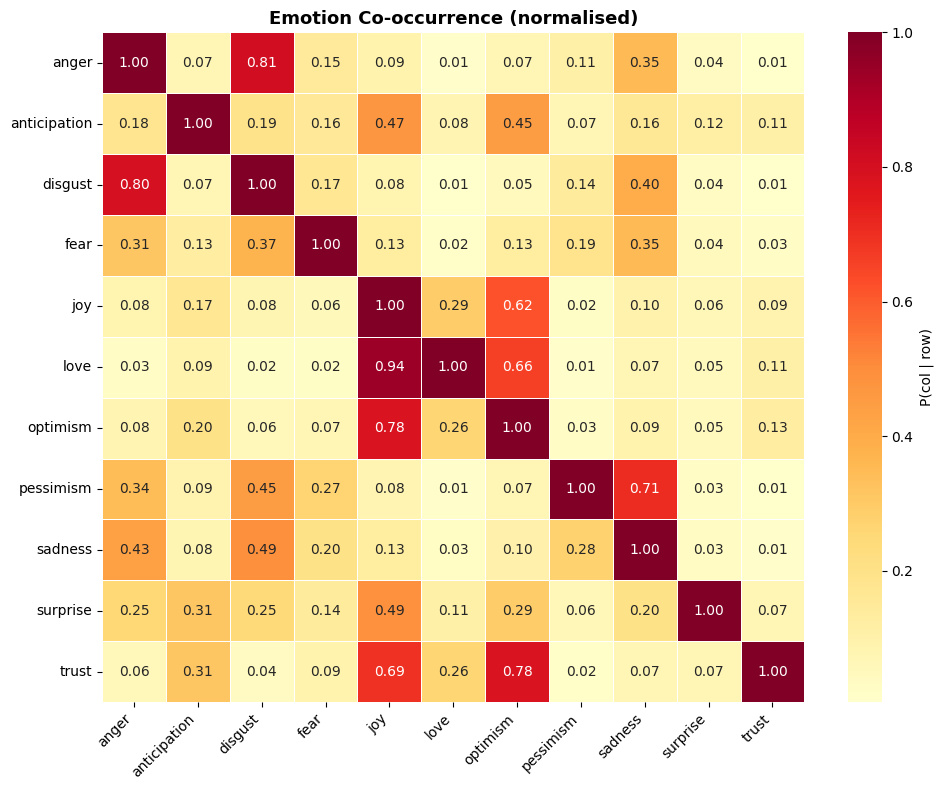

Co-occurrence heatmap saved.


In [ ]:





# --- Emotion co-occurrence heatmap ---
fig, ax = plt.subplots(figsize=(10, 8))

cooccurrence = df_all[EMOTIONS].T.dot(df_all[EMOTIONS])
# Normalise: P(j | i) = cooccurrence[i,j] / count[i]
norm = cooccurrence.values.diagonal()
cooccurrence_norm = cooccurrence.div(norm, axis=0)

sns.heatmap(
    cooccurrence_norm,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'P(col | row)'}
)
ax.set_title('Emotion Co-occurrence (normalised)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PROC_DIR, 'emotion_cooccurrence.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Co-occurrence heatmap saved.')

/tmp/ipykernel_28728/1516738163.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha='right')
/tmp/ipykernel_28728/1516738163.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha='right')
/tmp/ipykernel_28728/1516738163.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha='right')


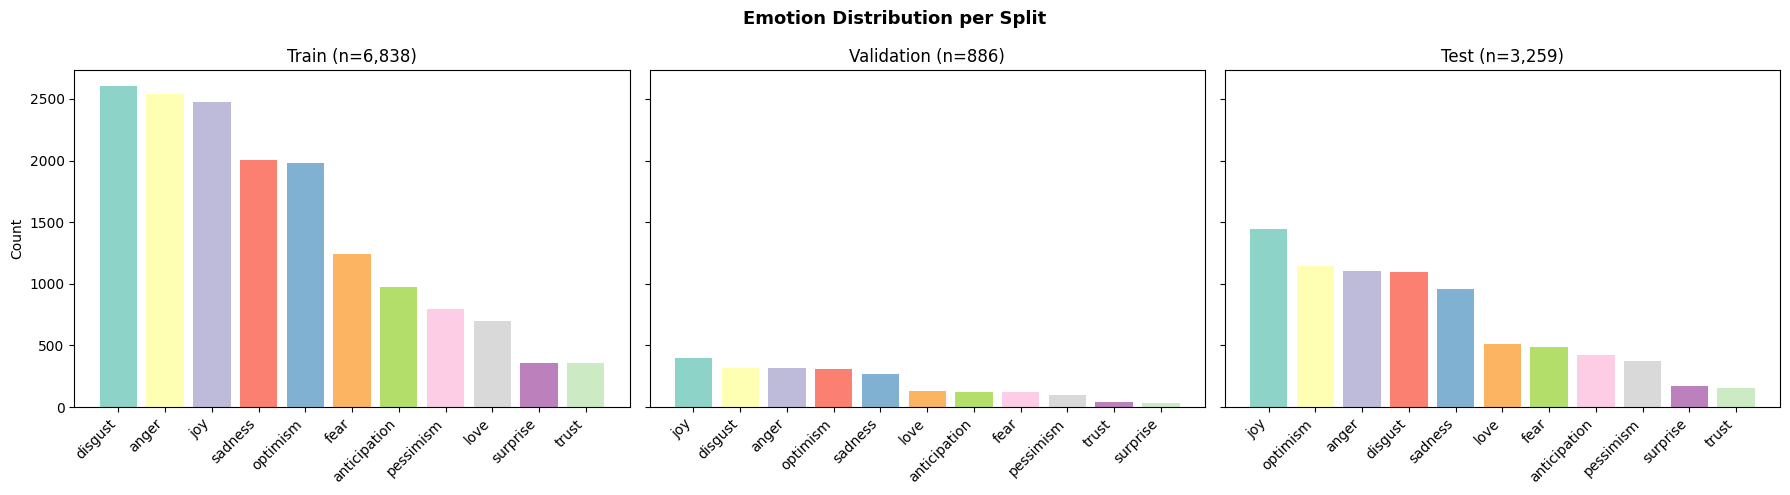

In [11]:
# --- Per-split emotion distribution ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Emotion Distribution per Split', fontsize=13, fontweight='bold')

for ax, (split_name, df_split) in zip(axes, [('Train', df_train), ('Validation', df_val), ('Test', df_test)]):
    counts = df_split[EMOTIONS].sum().sort_values(ascending=False)
    ax.bar(counts.index, counts.values, color=sns.color_palette('Set3', len(EMOTIONS)))
    ax.set_title(f'{split_name} (n={len(df_split):,})')
    ax.set_xticklabels(counts.index, rotation=45, ha='right')
    ax.set_ylabel('Count' if ax == axes[0] else '')

plt.tight_layout()
plt.savefig(os.path.join(PROC_DIR, 'emotion_per_split.png'), dpi=150, bbox_inches='tight')
plt.show()

**Αποτέλεσμα:** Τα 3 splits μετατράπηκαν σε pandas DataFrames με σχήματα (6838, 13), (886, 13) και (3259, 13). Τα emotion columns είναι πλέον integer (0/1) — από `bool` σε `int` για αριθμητικές πράξεις. Δημιουργείται και ένα ενοποιημένο `df_all` με column `split` που δείχνει την προέλευση κάθε γραμμής, χρήσιμο για συνολικά στατιστικά.

## 8. Αποθήκευση Raw Data σε Parquet

Αποθηκεύουμε τα DataFrames σε **Parquet format** — columnar binary format που προτιμάται έναντι CSV για τους εξής λόγους:
- **Μικρότερο μέγεθος** αρχείου λόγω columnar compression
- **Ταχύτερη ανάγνωση** — φορτώνει μόνο τις στήλες που χρειάζεσαι
- **Διατήρηση τύπων δεδομένων** — `int`, `string`, `bool` αποθηκεύονται σωστά χωρίς re-parsing

Τα επόμενα notebooks φορτώνουν από αυτά τα αρχεία αντί να ξανακατεβάζουν το dataset.

**Αποτέλεσμα — Class Imbalance:** Σύνολο 10.983 μοναδικά tweets, μέσο μήκος 94.8 χαρακτήρες (μέγιστο 160 — το Twitter limit της εποχής). Κρίσιμο εύρημα: η κατανομή των emotions είναι **πολύ άνιση**. Το `joy` (4.319 tweets) έχει σχεδόν **8 φορές** περισσότερα παραδείγματα από το `trust` (553) και το `surprise` (566). Αυτό το **class imbalance** θα αντιμετωπιστεί στο NB04 με `class_weight='balanced'`.

**Αποτέλεσμα — Multi-Label Φύση:** Μέσος αριθμός emotions ανά tweet: **2.37**, με πιο συνηθισμένη περίπτωση τα 2 emotions (40.9% των tweets). Μόνο 2.7% δεν έχουν κανένα emotion label. Αυτά τα ευρήματα επιβεβαιώνουν ότι πρέπει να αντιμετωπίσουμε το πρόβλημα ως **multi-label classification** — 11 ανεξάρτητες binary αποφάσεις — και όχι ως single-label.

In [12]:
train_path = os.path.join(RAW_DIR, 'train.parquet')
val_path   = os.path.join(RAW_DIR, 'validation.parquet')
test_path  = os.path.join(RAW_DIR, 'test.parquet')
all_path   = os.path.join(RAW_DIR, 'all.parquet')

df_train.to_parquet(train_path, index=False)
df_val.to_parquet(val_path,     index=False)
df_test.to_parquet(test_path,   index=False)
df_all.to_parquet(all_path,     index=False)

print('Data saved successfully!')
for path in [train_path, val_path, test_path, all_path]:
    size_kb = os.path.getsize(path) / 1024
    print(f'   {os.path.basename(path):20s}: {size_kb:.1f} KB')

Data saved successfully!
   train.parquet       : 575.1 KB
   validation.parquet  : 81.8 KB
   test.parquet        : 276.7 KB
   all.parquet         : 928.8 KB


**Αποτέλεσμα:** Δύο διαγράμματα δίπλα-δίπλα. **Αριστερά:** horizontal bar chart με τη συχνότητα κάθε emotion — το `joy` κυριαρχεί ενώ `surprise` και `trust` είναι σπάνια, φανερώνοντας το class imbalance. **Δεξιά:** multi-label distribution — η πλειοψηφία (40.9%) έχει ακριβώς 2 emotions. Αποθηκεύτηκε στο `data/processed/dataset_overview.png`.

![Dataset Overview — Emotion Frequency & Multi-label Distribution](../data/processed/dataset_overview.png)

**Αποτέλεσμα:** Το heatmap δείχνει P(j | i): αν ένα tweet έχει emotion i, πόσο πιθανό είναι να έχει και emotion j. Η διαγώνιος είναι πάντα 1.0 (κάθε emotion συν-εμφανίζεται με τον εαυτό του). Παρατηρούμε ισχυρές συσχετίσεις μεταξύ `joy`–`optimism` και `anger`–`disgust`, ενώ `surprise` έχει χαμηλή συν-εμφάνιση με όλα τα άλλα — επιβεβαιώνοντας την αμφίσημη φύση του. Αποθηκεύτηκε στο `data/processed/emotion_cooccurrence.png`.

![Emotion Co-occurrence Heatmap (Normalised)](../data/processed/emotion_cooccurrence.png)

**Αποτέλεσμα:** Η κατανομή των emotions είναι **παρόμοια** και στα τρία splits (train/validation/test) — το ίδιο pattern class imbalance εμφανίζεται παντού. Αυτό επιβεβαιώνει ότι η διαίρεση έγινε σωστά (stratified split) χωρίς distribution shift μεταξύ splits. Αποθηκεύτηκε στο `data/processed/emotion_per_split.png`.

![Emotion Distribution per Split](../data/processed/emotion_per_split.png)